In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("dataset.csv")

In [6]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
df.shape

(303, 14)

In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='target'>

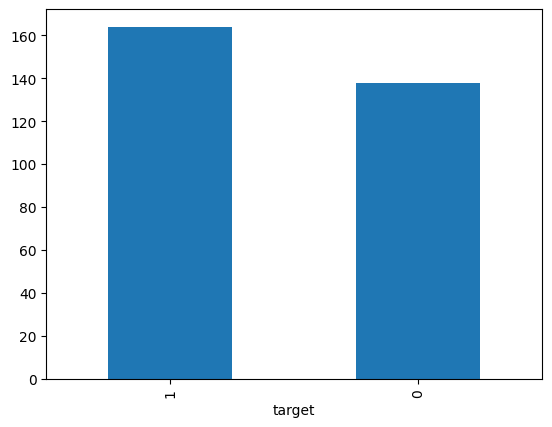

In [15]:
df['target'].value_counts().plot(kind='bar')

In [16]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

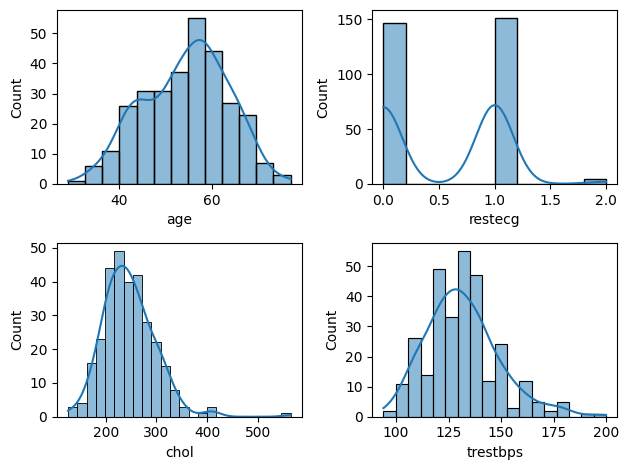

In [17]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)

plotting("age",1)
plotting("restecg",2)
plotting("chol",3)
plotting("trestbps",4)

plt.tight_layout()



In [18]:
cholesterol_mean = df.loc[df['chol'] != 0, 'chol'].mean()

# Step 2: Replace 0s with the calculated mean
df['chol'] = df['chol'].replace(0, cholesterol_mean)


In [19]:
df['chol']

,chol
0,233
1,250
2,204
3,236
4,354
...,...
298,241
299,264
300,193
301,131


In [20]:
bps = df.loc[df['trestbps'] != 0, 'trestbps'].mean()

df['trestbps'] = df['trestbps'].replace(0, bps)



In [21]:
!pip install sheryanalysis==0.1.0

In [22]:
import sheryanalysis
sheryanalysis.analyze(df)


🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (302, 14)


...


🔠 Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


INFO:sheryanalysis:
🔠 Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']



🔢 Numerical Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


INFO:sheryanalysis:
🔢 Numerical Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


{'shape': (302, 14),
 'columns': ['age',
  'sex',
  'cp',
  'trestbps',
  'chol',
  'fbs',
  'restecg',
  'thalach',
  'exang',
  'oldpeak',
  'slope',
  'ca',
  'thal',
  'target'],
 'dtypes': {'age': dtype('int64'),
  'sex': dtype('int64'),
  'cp': dtype('int64'),
  'trestbps': dtype('int64'),
  'chol': dtype('int64'),
  'fbs': dtype('int64'),
  'restecg': dtype('int64'),
  'thalach': dtype('int64'),
  'exang': dtype('int64'),
  'oldpeak': dtype('float64'),
  'slope': dtype('int64'),
  'ca': dtype('int64'),
  'thal': dtype('int64'),
  'target': dtype('int64')},
 'null_counts': {'age': 0,
  'sex': 0,
  'cp': 0,
  'trestbps': 0,
  'chol': 0,
  'fbs': 0,
  'restecg': 0,
  'thalach': 0,
  'exang': 0,
  'oldpeak': 0,
  'slope': 0,
  'ca': 0,
  'thal': 0,
  'target': 0},
 'total_rows': 302,
 'column_types': {'categorical': ['sex',
   'cp',
   'fbs',
   'restecg',
   'exang',
   'slope',
   'ca',
   'thal',
   'target'],
  'numerical': ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
  'd

<Axes: xlabel='sex', ylabel='count'>

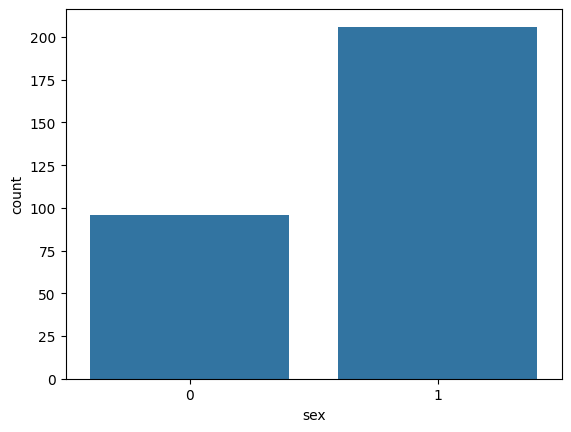

In [23]:
sns.countplot(x = df['sex'])

<Axes: >

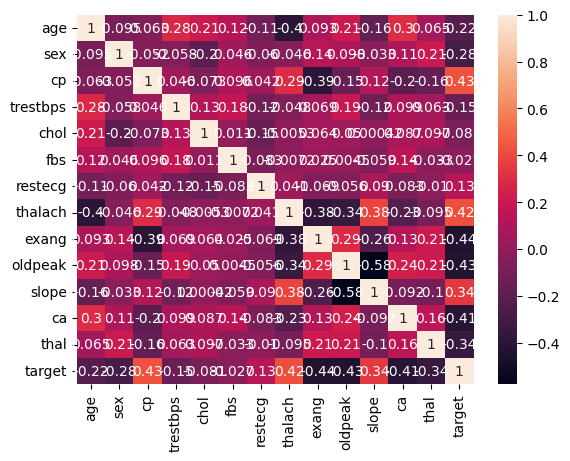

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [26]:
x=df.drop('target',axis=1)
y=df['target']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.2, random_state=42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

In [31]:
results=[]

In [32]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

In [33]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.7869, 'F1 Score': 0.8169},
 {'Model': 'KNN', 'Accuracy': 0.8033, 'F1 Score': 0.8333},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8197, 'F1 Score': 0.8451},
 {'Model': 'Decision Tree', 'Accuracy': 0.7541, 'F1 Score': 0.7826},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.8361, 'F1 Score': 0.8611}]

In [37]:
import joblib
joblib.dump(models['SVM (RBF Kernel)'],'SVM_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']